# Week 13 — Function 06

Focused, checksum-backed review of verified evidence through Week 11. No authoritative Week 12 or Week 13 returned output is treated as an observation.

## Table of contents

1. [Overview](#overview)
2. [Objectives](#objectives)
3. [Evidence provenance](#evidence-provenance)
4. [Environment and setup](#environment-setup)
5. [Data validation](#data-validation)
6. [Descriptive EDA](#descriptive-eda)
7. [Visual EDA](#visual-eda)
8. [GP model configuration](#gp-model-configuration)
9. [GP-UCB values](#gp-ucb-values)
10. [Reproducibility checks](#reproducibility-checks)
11. [Conclusions and next steps](#conclusions-next-steps)

<a id="overview"></a>
## 1. Overview

This notebook reviews one black-box function, presents bounded EDA, and surfaces the exact canonical Week 13 GP-UCB recommendation.

<a id="objectives"></a>
## 2. Objectives

Validate the cumulative evidence, describe the observed search history, inspect diagnostics, report the fitted GP configuration, and verify the proposed query.

<a id="evidence-provenance"></a>
## 3. Evidence provenance

Starter observations are combined only with returned pairs in the immutable canonical ledger. Missing Week 12 and Week 13 returns are not imputed.

<a id="environment-setup"></a>
## 4. Environment and setup

In [1]:
from pathlib import Path
import sys
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display, Markdown
repo_root=Path.cwd().resolve()
while not (repo_root/'Code').exists() and repo_root!=repo_root.parent: repo_root=repo_root.parent
function_root=repo_root/'Week_13'/'Function_06'
sys.path.insert(0,str(function_root/'02_Code'))
from analyse_week_13_function_06 import analyse


<a id="data-validation"></a>
## 5. Data validation

Reconstruct the function data and validate its recorded summary before analysis.

{'week': 13,
 'function': 6,
 'dimensions': 5,
 'starter_observations': 20,
 'recorded_pairs': 11,
 'total_verified_observations': 31,
 'best_query': 1,
 'best_input': [0.7281861047460138,
  0.1546925696237983,
  0.7325516687239811,
  0.6939965090690888,
  0.056401310518258585],
 'best_output': -0.7142649478202404,
 'latest_verified_query': 31,
 'latest_verified_input': [0.67859, 0.144728, 0.730278, 0.715653, 0.604728],
 'latest_verified_output': -1.154424131709899,
 'latest_improves_previous_best': False,
 'minimum_output': -2.5711696316081234,
 'mean_output': -1.4870581165549805,
 'standard_deviation': 0.46869277637573803,
 'evidence_gap': 'No verified Week 12 or Week 13 return is present; confirmed cumulative evidence is available through Week 11.',
 'interpretation': 'Within-function descriptive evidence; no causal or cross-function ranking claim.',
 'archive_integrity': 'Original repository Week 11 arrays remain quarantined; analysis uses independently recovered pairs from the can

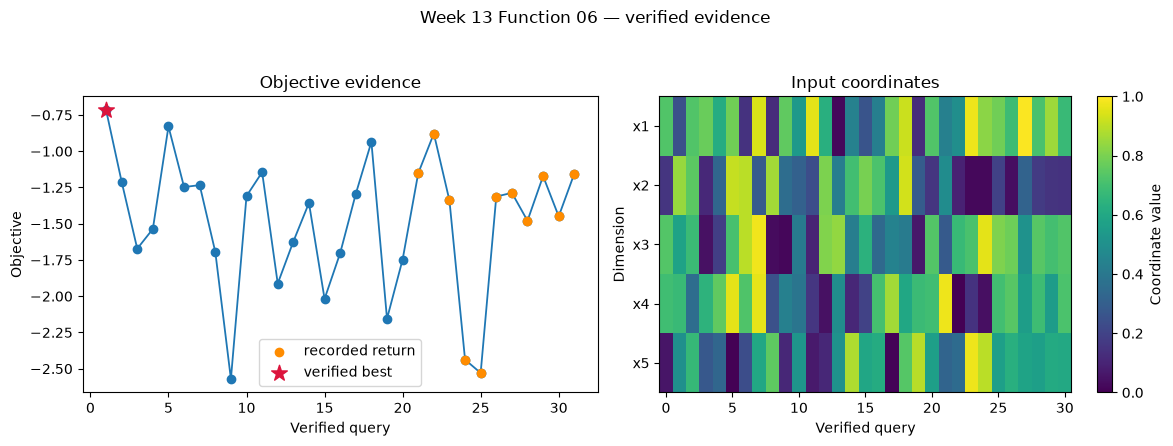

In [2]:
observations,summary,figure=analyse()
summary


<a id="descriptive-eda"></a>
## 6. Descriptive EDA

Inspect a bounded observation preview, full per-variable summary statistics, and the persisted function summary.

In [3]:
display(observations.head(10))
display(observations.describe().T)
display(pd.DataFrame([summary]))

,query,evidence,x1,x2,x3,x4,x5,objective
0,1,starter,0.728186,0.154693,0.732552,0.693997,0.056401,-0.714265
1,2,starter,0.242384,0.844100,0.577809,0.679021,0.501953,-1.209955
2,3,starter,0.729523,0.748106,0.679775,0.356552,0.671054,-1.672200
3,4,starter,0.770620,0.114404,0.046780,0.648324,0.273549,-1.536058
4,5,starter,0.618812,0.331802,0.187288,0.756238,0.328835,-0.829237
5,6,starter,0.784958,0.910682,0.708120,0.959225,0.004911,-1.247049
6,7,starter,0.145111,0.896685,0.896322,0.726272,0.236272,-1.233786
7,8,starter,0.945069,0.288459,0.978806,0.961656,0.598016,-1.694343
8,9,starter,0.125720,0.862725,0.028544,0.246605,0.751206,-2.571170
9,10,starter,0.757594,0.355831,0.016523,0.434207,0.112433,-1.309116


,count,mean,std,min,25%,50%,75%,max
query,31.0,16.000000,9.092121,1.000000,8.500000,16.000000,23.500000,31.000000
x1,31.0,0.616569,0.277732,0.021735,0.436499,0.711755,0.783919,0.994993
x2,31.0,0.421033,0.308079,0.022732,0.154693,0.316819,0.731862,0.931871
x3,31.0,0.547412,0.291612,0.016523,0.376849,0.672921,0.735474,0.978806
x4,31.0,0.532150,0.289599,0.000007,0.301579,0.648324,0.710326,0.972905
x5,31.0,0.488355,0.276033,0.004911,0.298435,0.564013,0.622136,0.974790
objective,31.0,-1.487058,0.476440,-2.571170,-1.698451,-1.339542,-1.190834,-0.714265


,week,function,dimensions,starter_observations,recorded_pairs,total_verified_observations,best_query,best_input,best_output,latest_verified_query,latest_verified_input,latest_verified_output,latest_improves_previous_best,minimum_output,mean_output,standard_deviation,evidence_gap,interpretation,archive_integrity
0,13,6,5,20,11,31,1,"[0.7281861047460138, 0.1546925696237983, 0.732...",-0.714265,31,"[0.67859, 0.144728, 0.730278, 0.715653, 0.604728]",-1.154424,False,-2.57117,-1.487058,0.468693,No verified Week 12 or Week 13 return is prese...,Within-function descriptive evidence; no causa...,Original repository Week 11 arrays remain quar...


<a id="visual-eda"></a>
## 7. Visual EDA

Display the function-level diagnostic figure generated from verified observations.

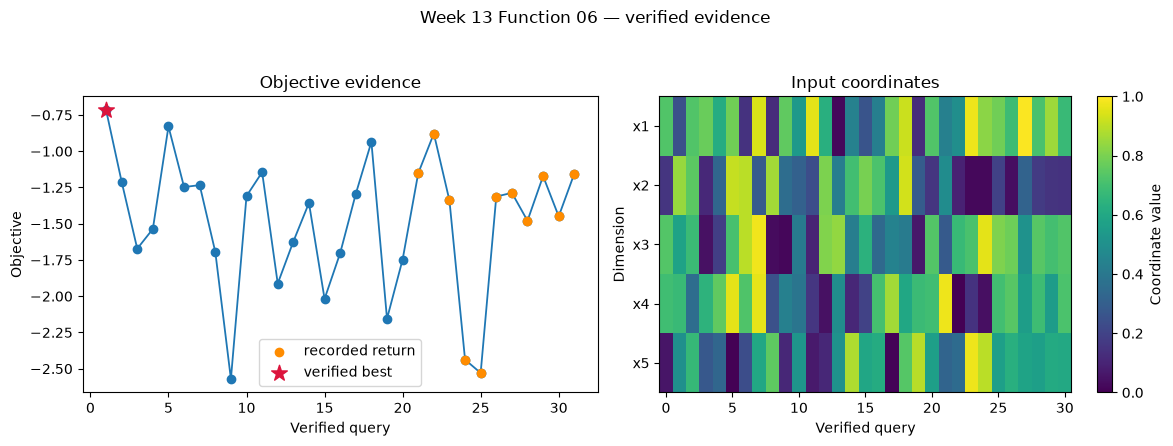

In [4]:
display(figure)

<a id="gp-model-configuration"></a>
## 8. GP model configuration

Load the canonical Week 13 GP-UCB row and expose the fitted kernel, candidate count, kappa, seed, and evidence count.

In [5]:
proposal_ledger = pd.read_csv(repo_root / 'Results' / 'week_13_gp_ucb_proposals.csv')
proposal = proposal_ledger.loc[proposal_ledger['function'].eq(6)].iloc[0]
display(proposal[['observation_count', 'kernel', 'candidate_count', 'kappa', 'random_seed']].to_frame('value'))

,value
observation_count,31
kernel,"2.17**2 * Matern(length_scale=[1.15, 0.81, 1.1..."
candidate_count,20000
kappa,0.1
random_seed,4206


<a id="gp-ucb-values"></a>
## 9. GP-UCB values

Report the exact portal-formatted query, predicted mean, predictive uncertainty, and acquisition value.

In [6]:
display(proposal[['submission_query', 'predicted_mean', 'predictive_std', 'ucb_score', 'duplicate_at_6dp', 'status']].to_frame('value'))

,value
submission_query,0.542093-0.205654-0.578843-0.946831-0.036709
predicted_mean,-0.478081
predictive_std,0.139662
ucb_score,-0.464115
duplicate_at_6dp,False
status,validated_proposal_only_week_12_and_13_returns...


<a id="reproducibility-checks"></a>
## 10. Reproducibility checks

Confirm data integrity and consistency between the focused notebook and the canonical proposal ledger.

In [7]:
assert observations.shape[0]==summary['total_verified_observations']
assert observations.filter(regex=r'^x').to_numpy().min()>=0
assert observations.filter(regex=r'^x').to_numpy().max()<=1
assert observations['objective'].notna().all()
print('All Week 13 Function 06 checks passed.')
assert summary['function'] == 6
assert int(proposal['observation_count']) == observations.shape[0]
assert not bool(proposal['duplicate_at_6dp'])
assert float(proposal['kappa']) == 0.1
print('All Week 13 Function 06 workflow checks passed.')

All Week 13 Function 06 checks passed.
All Week 13 Function 06 workflow checks passed.


<a id="conclusions-next-steps"></a>
## 11. Conclusions and next steps

Summarise the evidence-backed result without promoting a proposal to an observed return.

In [8]:
display(Markdown(f"**Verified observations:** {int(summary['total_verified_observations'])}  \n"f"**Best verified output:** {float(summary['best_output']):.8g}  \n"f"**Week 13 GP-UCB query:** `{proposal['submission_query']}`  \n"f"**UCB score:** {float(proposal['ucb_score']):.8g}  \n""Next step: append this point only after an authoritative returned output is available."))

**Verified observations:** 31  
**Best verified output:** -0.71426495  
**Week 13 GP-UCB query:** `0.542093-0.205654-0.578843-0.946831-0.036709`  
**UCB score:** -0.46411463  
Next step: append this point only after an authoritative returned output is available.